In [1]:
import os, sys, importlib,pathlib
import pandas as pd
import matplotlib.pyplot as plt
sys.path.append(os.path.abspath(".."))
import numpy as np
# my utils
from utils import axe_classification


d:\miniconda3\envs\irg_env\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
df_predicted=pd.read_parquet("../external_data\embeddings_all\df_all_3emb_predicted.parquet")
print(df_predicted.axe.value_counts(dropna=False),"\n")
print(df_predicted.final_axe.value_counts(dropna=False))
display(df_predicted.head())

axe
3          1107
1           684
None        617
2           252
4            46
1; 3         11
2; 3          8
1; 2          6
1; 2; 3       1
3; 1          1
3; 4          1
Name: count, dtype: int64 

final_axe
3          1324
1           811
2           269
1; 3        179
2; 3         74
4            46
1; 2; 3      18
1; 2         12
3; 4          1
Name: count, dtype: int64


,halId_s,uri_s,docType_s,title_s,subTitle_s,authFullName_s,authIdHal_s,labStructName_s,author_primarystructure_s,collName_s,...,fnege_year,axes_vec,axe1,axe2,axe3,axe4,emb_title_s,emb_keyword_s,emb_abstract_s,final_axe
14,hal-05354091,https://hal.science/hal-05354091v1,COMM,Les jeux vidéo FLOSS dans l’enseignement supér...,None,Philippe Lépinard,philippe-lepinard,Institut de Recherche en Gestion,1004418_Institut de Recherche en Gestion,Sciences de l'Homme et de la Société; Biblioth...,...,2022,"[0, 0, 1, 0]",0,0,1,0,"[-0.07416533, -0.02507004, -0.056212127, -0.00...","[-0.038245093, -0.003676773, -0.055256307, -0....","[-0.0627323, -0.012661392, -0.04260565, -0.003...",3
20,hal-05321456,https://hal.u-pec.fr/hal-05321456v1,COUV,Unlocking Organizational Identity,A Consultant’s Playbook for Inclusion Advocacy,Éric Gautier Laurent; Catherine Voynnet-Fourboul,eric-gautier; catherine-voynnet-fourboul,Institut de Recherche en Gestion; Laboratoire ...,1004418_Institut de Recherche en Gestion;10964...,Sciences de l'Homme et de la Société; Universi...,...,2022,"[0, 0, 1, 0]",0,0,1,0,"[-0.022757635, -0.0064444183, -0.042470817, 0....","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",3
33,hal-05302743,https://hal.science/hal-05302743v1,ART,Les Remote Carriers dans le combat collaborati...,None,Juliette Frédy; Cécile Godé; Philippe Lépinard,cecile-gode; philippe-lepinard,Centre d'Études et de Recherche en Gestion d'A...,420786_Université Paris-Est Créteil Val-de-Mar...,Sciences de l'Homme et de la Société; Universi...,...,2022,"[0, 0, 1, 0]",0,0,1,0,"[-0.03761582, -0.006678919, -0.009912152, 0.01...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[-0.074023664, 0.021094285, -0.00791859, 0.025...",3
40,hal-05295448,https://hal.science/hal-05295448v1,ART,Frugalité technologique et ludopédagogie en ma...,None,Philippe Lépinard; Prabpreet Singh,philippe-lepinard,Institut de Recherche en Gestion,1004418_Institut de Recherche en Gestion;17672...,Sciences de l'Homme et de la Société; Biblioth...,...,2022,"[0, 0, 1, 0]",0,0,1,0,"[-0.081040576, 0.0018408684, -0.008541116, 0.0...","[-0.062362764, -0.028598065, -0.051758498, -0....","[-0.07686497, -0.0064801904, -0.03617584, -0.0...",3
42,hal-05288245,https://hal.science/hal-05288245v1,COUV,Perspectives pédagogiques ! Frugalité technolo...,None,Philippe Lépinard,philippe-lepinard,Institut de Recherche en Gestion,1004418_Institut de Recherche en Gestion,Sciences de l'Homme et de la Société; Biblioth...,...,2022,"[0, 0, 1, 0]",0,0,1,0,"[-0.09261081, -0.01070483, -0.017841782, 0.000...","[-0.054620333, -0.028326109, -0.0541471, 0.001...","[-0.07495657, 0.0016563429, -0.018859863, 0.01...",3


## try3:

In [3]:

"""
1️⃣ 把文章当作“节点”
2️⃣ 用“关系”来定义引力（而不是直接用坐标）
3️⃣ 用 force-directed layout 来“生成坐标”


"""
import networkx as nx

df_predicted=pd.read_parquet("../external_data\embeddings_all\df_all_3emb_predicted.parquet")
df=df_predicted.copy()

def parse_axes(x):
    if pd.isna(x):
        return []
    return [a.strip() for a in str(x).split(';')]

df['axe_list'] = df['final_axe'].apply(parse_axes)
all_axes = sorted({a for axes in df['axe_list'] for a in axes})
# display(df["axe_list"].head())

#Step 2：合并三种 embedding（稳健版本）
def combine_embeddings(row, w_title=1.0, w_kw=1.2, w_abs=1.5):# 给axe加权
    vecs = []
    weights = []

    if isinstance(row['emb_title_s'], np.ndarray):
        vecs.append(row['emb_title_s'])
        weights.append(w_title)

    if isinstance(row['emb_keyword_s'], np.ndarray):
        vecs.append(row['emb_keyword_s'])
        weights.append(w_kw)

    if isinstance(row['emb_abstract_s'], np.ndarray):
        vecs.append(row['emb_abstract_s'])
        weights.append(w_abs)

    if not vecs:
        return None

    return np.average(vecs, axis=0, weights=weights)
df['combined_emb'] = df.apply(combine_embeddings, axis=1)

X = np.vstack(df['combined_emb'].dropna().values)
df_plot = df.loc[df['combined_emb'].notna()].copy()


# def main_axe(axes):
#     return axes[0] if axes else None
## 选取axe
# df_plot['main_axe'] = df_plot['axe_list'].apply(main_axe)# main/explode?

##!!!!
# 👉 同一篇文章的多个副本，在力系统中被当成多个“几乎重合的点”
# 这会导致：局部形成极强“塌缩”，spring layout 把一切压向中心
# 文章是点（node），axes 是“隐含结构”，不是点的复制器, 所以不应该按照axe进行explode！

# def explode_by_col(df, col, col_exploded):
#     df = df.copy()
#     df[col_exploded] = df[col].fillna('nan').astype(str).str.split("[,;]") # axe中有nan所以type:objet，先变成str
#     df = df.explode(col_exploded)
#     df[col_exploded] = df[col_exploded].str.strip()
#     return df[df[col_exploded].notna() & (df[col] != "")]
# df_plot_exploded=explode_by_col(df=df_plot, col="final_axe", col_exploded="final_axe_exploded")

# print(df_plot_exploded.final_axe_exploded.value_counts(dropna=False))

In [110]:
# df_plot=df_plot_exploded.copy()

#Step 1：节点 = 文章
G = nx.Graph()
for idx, row in df_plot.iterrows():
    G.add_node(
        idx,
        axes=row['axe_list'],          # 保留完整列表
        emb=row['combined_emb'],       # embedding
        n_axes=len(row['axe_list'])    # 用于可视化大小或透明度
    )

# Step 2：定义三种“力”
from sklearn.metrics.pairwise import cosine_similarity

#力 1：语义相似 → 吸引（弱）# 加强最近的10且sim大于0,85的文章之间的力？

X = np.vstack(df_plot['combined_emb'])
S = cosine_similarity(X)

K = 10 # 每个点只连最近的 K 个
sim_thresh = 0.85

for i in range(len(df_plot)):
    topk_idx = np.argpartition(-S[i], K+1)[:K+1]
    for j in topk_idx:
        if i < j and S[i,j] > sim_thresh:
            G.add_edge(i, j, weight=0.3)



# # === 3. axe 虚拟节点 (弱吸引)===
# 先假设一个axe的虚拟节点，让文章与axe节点项链，历遍所有文章时候，layout会自动拉拢同一axe下的所有文章
for idx, row in df_plot.iterrows():
    for axe in row['axe_list']:
        axe_node = f"AXE_{axe}"  
        if axe_node not in G:
            G.add_node(axe_node, type='axe') 
        G.add_edge(idx, axe_node, weight=0.1)  

        
# # 力 2：同 axe → 强吸引（关键）
# # axe 强吸引看起来“更清晰”，是因为它在“强行展示标签”，而 axe 虚拟节点展示的是“真实语义张力”。
# all_axes = sorted({a for axes in df['final_axe'] for a in axes})
# for axe in all_axes:
#     nodes = df_plot.index
#     # axe 内所有文章两两强连接
#     for i in nodes:
#         for j in nodes:
#             if i < j:
#                 G.add_edge(i, j, weight=0.7)
   
# 力 3：多 axe 文章 → 桥梁
# 多 axe 的文章自然成为桥，不需要特殊处理，它已经连着多个团。

In [ ]:
pos = nx.spring_layout(
    G,
    weight='weight',
    iterations=100,
    seed=42,
    # k=2, # k 越大，节点之间的自然间距越大，k 不是在“增加真实结构”，而是在给结构一个“能展开的空间”。
    # k controls the global repulsion scale and thus prevents excessive spatial collapse induced by multiple weak attractors.
)

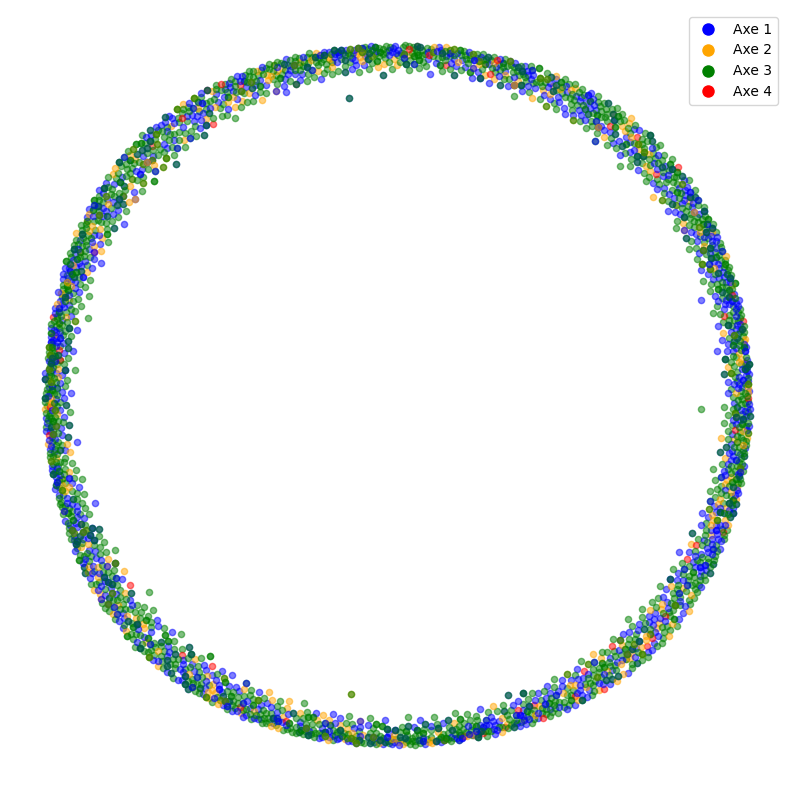

In [112]:
plt.figure(figsize=(10, 10))

# 保留原来的自动颜色映射
# 假设你已经有颜色字典或者 cmap，这里我们用 colors 映射 axe
colors = {1:'blue', 2:'orange', 3:'green', 4:'red'}
axe_label={"1":"Performances et responsabilités",
           "2":"Société de services et services à la société",
           "3":"Innovations, transformations et résistances organisationnelles et sociétales",
           "4":"Ouvrages pédagogiques"}

s_size = 20      # 点大小
alpha_val = 0.5  # 透明度

for idx, row in df_plot.iterrows():
    x, y = pos[idx]
    axes = row['axe_list']
    if len(axes) == 1:
        # 单轴文章 → 一个点
        plt.scatter(x, y, c=colors[int(axes[0])], s=s_size, alpha=alpha_val)
    else:
        # 多轴文章 → 同位置画多个颜色点
        for axe in axes:
            plt.scatter(x, y, c=colors[int(axe)], s=s_size, alpha=alpha_val)

# show legend ：只显示单轴颜色对应的 axe
from matplotlib.lines import Line2D

legend_elements = [Line2D([0],[0], marker='o', color='w', label=f"Axe {axe}",
                    markerfacecolor=color, markersize=10)
                   for axe, color in colors.items()]
plt.legend(handles=legend_elements, loc='best')

plt.axis('off')
plt.show()

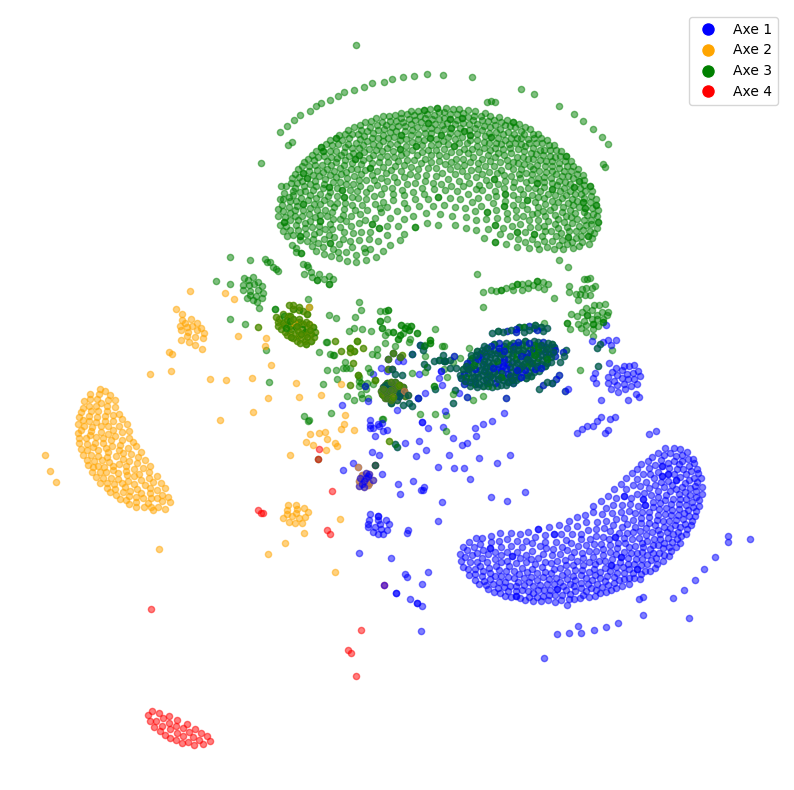

In [46]:
plt.figure(figsize=(10, 10))

# 保留原来的自动颜色映射
# 假设你已经有颜色字典或者 cmap，这里我们用 colors 映射 axe
colors = {1:'blue', 2:'orange', 3:'green', 4:'red'}
axe_label={"1":"Performances et responsabilités",
           "2":"Société de services et services à la société",
           "3":"Innovations, transformations et résistances organisationnelles et sociétales",
           "4":"Ouvrages pédagogiques"}

s_size = 20      # 点大小
alpha_val = 0.5  # 透明度

for idx, row in df_plot.iterrows():
    x, y = pos[idx]
    axes = row['axe_list']
    if len(axes) == 1:
        # 单轴文章 → 一个点
        plt.scatter(x, y, c=colors[int(axes[0])], s=s_size, alpha=alpha_val)
    else:
        # 多轴文章 → 同位置画多个颜色点
        for axe in axes:
            plt.scatter(x, y, c=colors[int(axe)], s=s_size, alpha=alpha_val)

# show legend ：只显示单轴颜色对应的 axe
from matplotlib.lines import Line2D

legend_elements = [Line2D([0],[0], marker='o', color='w', label=f"Axe {axe}",
                    markerfacecolor=color, markersize=10)
                   for axe, color in colors.items()]
plt.legend(handles=legend_elements, loc='best')

plt.axis('off')
plt.show()

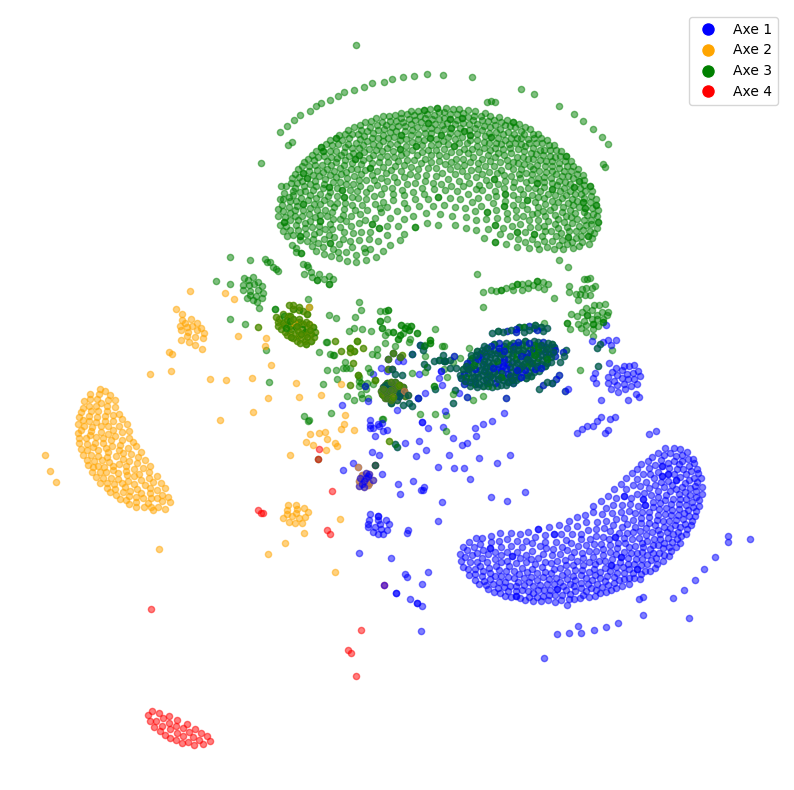

In [113]:
importlib.reload(topic_modeling)
from utils.topic_modeling import preprocess_df_for_topic_modeling, generate_force_scatterplot
df_predicted=pd.read_parquet("../external_data\embeddings_all\df_all_3emb_predicted.parquet")
df_plot=preprocess_df_for_topic_modeling(df_predicted)
generate_force_scatterplot(df_plot)

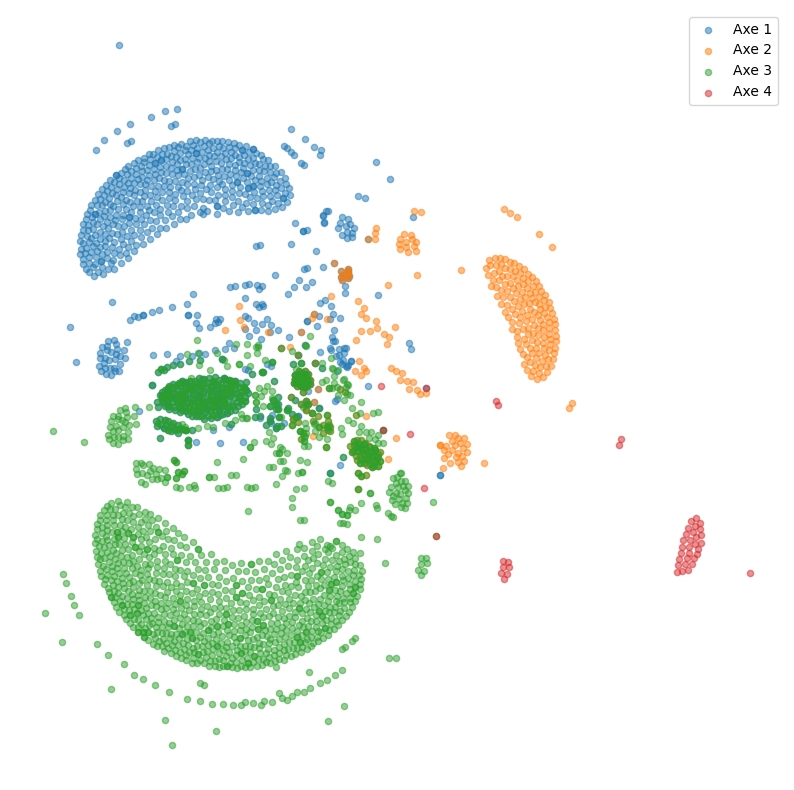

In [ ]:
#
# pos = nx.spring_layout(
#     G,
#     weight='weight',
#     iterations=100,
#     seed=42,
#     # k=2, # k 越大，节点之间的自然间距越大，k 不是在“增加真实结构”，而是在给结构一个“能展开的空间”。
#     # k controls the global repulsion scale and thus prevents excessive spatial collapse induced by multiple weak attractors.
# )

# plt.figure(figsize=(10, 10))
# for axe, g in df_plot.groupby('final_axe_exploded'):
#     idxs = g.index
#     plt.scatter(
#         [pos[i][0] for i in idxs],
#         [pos[i][1] for i in idxs],
#         s=20,
#         alpha=0.5,
#         label=f"Axe {axe}"
#     )

# plt.legend()
# plt.axis('off')
# plt.show()


## within-axe topic modeling

In [3]:
import os, sys, importlib, time
import pandas as pd
sys.path.append(os.path.abspath(".."))
from utils import topic_modeling
from utils.HAL_search_api import build_period
from bertopic import BERTopic
from umap import UMAP


In [34]:
df_predicted=pd.read_parquet("../external_data\embeddings_all\df_all_3emb_predicted.parquet")
print(len(df_predicted))

# display(df_predicted.head())
# print(df_predicted.columns.to_list())

# def filter_by_date(df):
#     start_date, end_date=build_period(start_year=2025, start_month=1,end_year=2025, end_month=12)
#     print(f"[period] {start_date}~{end_date}")
    
#     date_col="submittedDate_s"
#     if start_date is not None:
#         df = df[df[date_col] >= start_date]
#     if end_date is not None:
#         df = df[df[date_col] <= end_date]
    
#     return df


# df_predicted2025=filter_by_date(df_predicted)
# print(len(df_predicted),len(df_predicted2025))
# display(df_predicted2025.head())


2734


In [39]:
importlib.reload(topic_modeling)
from utils.topic_modeling import preprocess_df_for_topic_modeling,  get_topics_per_axe, plot_topics_wc

axe_id=["3"]
min_topic_size=30

#---------------------------------------------
df=preprocess_df_for_topic_modeling(df_predicted)
topic_model=get_topics_per_axe(df, axe_id=axe_id,col_text='clean_text', min_topic_size=min_topic_size)
topic_info = topic_model.get_topic_info()   
display(topic_info.head())

2026-01-26 10:38:39,937 - BERTopic - Embedding - Transforming documents to embeddings.


[INFO] axe ['3']: 1596 texts!


Batches: 100%|██████████| 50/50 [00:22<00:00,  2.25it/s]
2026-01-26 10:39:08,274 - BERTopic - Embedding - Completed ✓
2026-01-26 10:39:08,274 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-01-26 10:39:10,731 - BERTopic - Dimensionality - Completed ✓
2026-01-26 10:39:10,732 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-01-26 10:39:10,764 - BERTopic - Cluster - Completed ✓
2026-01-26 10:39:10,764 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-01-26 10:39:10,849 - BERTopic - Representation - Completed ✓


[INFO] min_topic_size : 30
1596 texts => 3 topics!
[RUNTIME]: 30.93 sec!


,Topic,Count,Name,Representation,Representative_Docs
0,-1,52,-1_stratégique_stratégie_pratique_foucault,"[stratégique, stratégie, pratique, foucault, p...",[approche discursif stratégie approche discurs...
1,0,1492,0_management_recherche_innovation_social,"[management, recherche, innovation, social, re...",[regard croisé compétence consommateur vers no...
2,1,52,1_parfumerie_siècle_xixe_perfumery,"[parfumerie, siècle, xixe, perfumery, luxe, pa...",[parfumerie parisien xixe siècle fabrique indu...


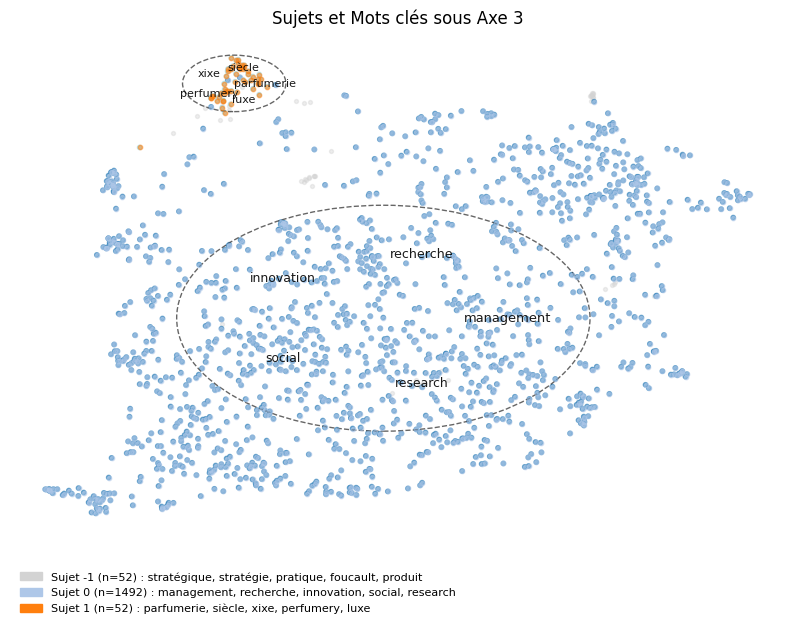

In [50]:
importlib.reload(topic_modeling)
from utils.topic_modeling import generate_topics_keywords_scatterplot
fig=generate_topics_keywords_scatterplot(topic_model, df, col_text="clean_text",axe_id=axe_id, N_WORDS = 5)

In [ ]:

axe_id=["3"]
min_topic_size=30
N_WORDS=5
#---------------------------------------------
df=preprocess_df_for_topic_modeling(df_predicted)
topic_model=get_topics_per_axe(df, axe_id=axe_id,col_text='clean_text', min_topic_size=min_topic_size)
topic_info = topic_model.get_topic_info()   
display(topic_info.head())
from utils.topic_modeling import generate_topics_keywords_scatterplot
fig=generate_topics_keywords_scatterplot(topic_model, df, col_text="clean_text",axe_id=axe_id, N_WORDS = N_WORDS)

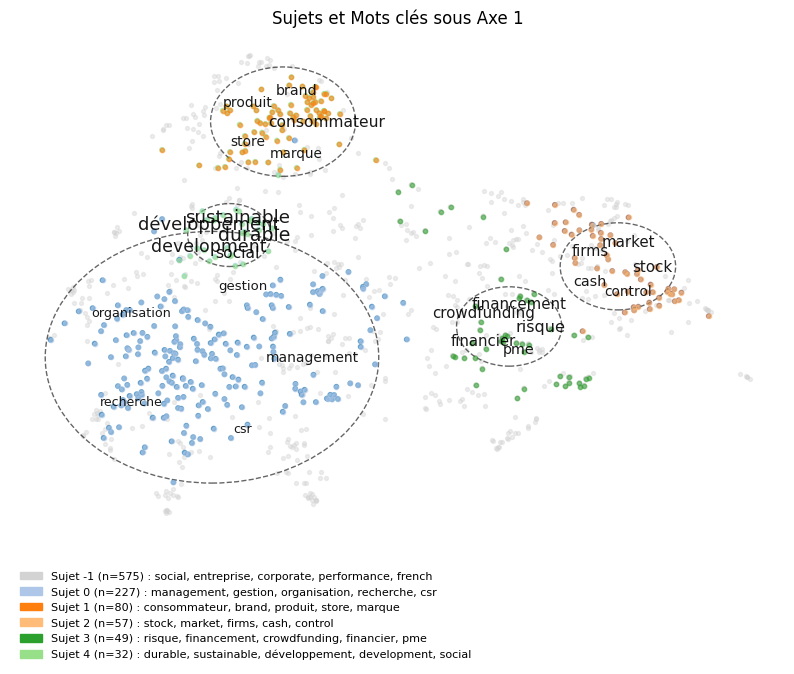

In [ ]:
### TEST VIS
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import Circle


# axe_id="1"
N_WORDS = 5

cmap = plt.get_cmap("tab20")  #Set2, tab20

# 提取文本的emb和topic
embeddings = topic_model.embedding_model.embed(texts)
topics = topic_model.topics_#topics list

##umap降维
umap_2d = UMAP(
    n_neighbors=15,
    n_components=2,
    min_dist=0.1,
    metric="cosine",
    random_state=42
)

## ================== 文章坐标点
coords = umap_2d.fit_transform(embeddings)
df_vis = pd.DataFrame({
    "x": coords[:, 0],
    "y": coords[:, 1],
    "topic": topics
})

## ==================topics中心点
topic_centers = (
    df_vis[df_vis.topic != -1]
    .groupby("topic")[["x", "y"]]
    .mean()
)
#topic的关键词
def topic_label(topic_id, n=5):
    return "\n".join([w for w, _ in topic_model.get_topic(topic_id)[:n]])
topic_centers["label"] = topic_centers.index.map(topic_label)
# print(topic_centers)

# 关键词的权重
def get_topic_words_with_weights(topic_id, n=8):
    return topic_model.get_topic(topic_id)[:n]

fig, ax = plt.subplots(figsize=(10, 8))
## ====================坐标点颜色
# 1️⃣ outliers (-1)：灰色
mask_outlier = df_vis.topic == -1
ax.scatter(
    df_vis.loc[mask_outlier, "x"],
    df_vis.loc[mask_outlier, "y"],
    c="lightgrey",
    alpha=0.4,
    s=8,
    # label="Outliers (-1)"
)

# 2️⃣ 正常 topics点
mask_topic = df_vis.topic != -1
scatter = ax.scatter(
    df_vis.loc[mask_topic, "x"],
    df_vis.loc[mask_topic, "y"],
    c=df_vis.loc[mask_topic, "topic"],
    cmap=cmap,#"Set2",#tab20
    alpha=0.6,
    s=10
)



# ===== 参数=====
# CIRCLE_RADIUS = 1      # ⭐ 固定半径（UMAP 空间）
MIN_RADIUS = 0.5
MAX_RADIUS = 2.0

BASE_FONT = 8
FONT_SCALE = 50          # 控制权重 → 字体大小


# =======Layout keywords========
for topic_id, row in topic_centers.iterrows():
    # 跳过 outliers（一般不画）
    if topic_id == -1:
        continue

    cx, cy = row.x, row.y
    # 取 topic count
    topic_info = topic_model.get_topic_info()
    topic_count = topic_info.loc[
        topic_info.Topic == topic_id, "Count"
    ].values[0]
    
    # ===== 计算圆半径（随 count 变化） =====
    # 线性缩放到 MIN_RADIUS ~ MAX_RADIUS
    # 可以根据 count 的全局最大最小值来缩放
    all_counts = topic_info[topic_info.Topic != -1]["Count"].values
    min_count, max_count = all_counts.min(), all_counts.max()

    # 防止 max_count == min_count
    if max_count == min_count:
        radius = (MIN_RADIUS + MAX_RADIUS) / 2
    else:
        radius = MIN_RADIUS + (topic_count - min_count) / (max_count - min_count) * (MAX_RADIUS - MIN_RADIUS)

    
    # ===== 画圆 =====
    circle = Circle(
        (cx, cy),
        radius=radius,
        edgecolor="black",
        facecolor="none",
        linestyle="--",
        linewidth=1,
        alpha=0.6
    )
    plt.gca().add_patch(circle)

    # ===== 画关键词 =====
    words = sorted(
        get_topic_words_with_weights(topic_id, n=N_WORDS),
        key=lambda x: x[1],
        reverse=True
    )

    for i, (word, weight) in enumerate(words):
        angle = 2 * np.pi * i / N_WORDS
        # 文字放在圆的  50% 半径处
        r_text = radius * 0.6
        # fontsize = 8 + (weight ** 0.5) * 35
        fontsize=BASE_FONT + weight * FONT_SCALE
        fontsize = np.clip(fontsize, 5, 20)

        x = cx + r_text * np.cos(angle)
        y = cy + r_text * np.sin(angle)

        plt.text(
            x,
            y,
            word,
            fontsize=fontsize,
            ha="center",
            va="center",
            alpha=0.9
        )
        
#============================================================================
plt.title(f"Sujets et Mots clés sous Axe {axe_id}")

# SHOW topics legend
topics_sorted = sorted(df_vis.topic.unique())
handles = []

for idx, topic_id in enumerate(topics_sorted):
    mask = df_vis.topic == topic_id
    if topic_id == -1:
        color = "lightgrey"
        # label = "Topic (-1)"
        # continue
        
        
    else:
        color = cmap(idx % 20)  # 循环颜色
        plt.scatter(
            df_vis.loc[mask, "x"],
            df_vis.loc[mask, "y"],
            c=[color],
            alpha=0.5,
            s=10
        )

    # 获取前 N 个关键词
    top_words = [w for w, _ in get_topic_words_with_weights(topic_id, n=N_WORDS)]
    # 获取 topic count
    topic_count = topic_model.get_topic_info().loc[
        topic_model.get_topic_info().Topic == topic_id, "Count"
    ].values[0]

    label = f"Sujet {topic_id} (n={topic_count}) : {', '.join(top_words)}"
    handles.append(mpatches.Patch(color=color, label=label))


# ===== 把 legend 放在图下方 =====
fig.subplots_adjust(bottom=0.25)  # 给 legend 留空间

ax.legend(
    handles=handles,
    # title="Sujets",
    loc="upper left",
    bbox_to_anchor=(0, -0.05),  # y小于0说明在图的下方
    fontsize=8,
    ncol=1,      # 每个 topic 一行（竖向）
    frameon=False
)
# loc 决定“legend 自己的哪个角”
# bbox_to_anchor 决定“这个角要贴在图的哪个位置”
ax.set_axis_off()

plt.show()

In [43]:
topic_model.visualize_documents(
    texts,
    hide_annotations=False
)
# 👉 你要看：
# 不同 topic 是否空间上分离？
# 是否存在多个 topic 完全重叠？
# -1（outlier）是否占很大面积？

In [38]:
topic_model.visualize_heatmap()


In [39]:
topic_model.visualize_hierarchy()


In [ ]:

topic_model=topic_model4
topic_info=topic_info4

axe_id='4'
df_axe = df[df['axe_list'].apply(lambda x: axe_id in x)].copy()
#=================================================
rep_titles = []

for topic_id in topic_info['Topic']:
    rep_docs = topic_model.get_representative_docs(topic_id)  # 或使用 topic_info['Representative_Docs']
    df_rep = df_axe[df_axe['clean_text'].isin(rep_docs)]
    titles = df_rep['title_s'].tolist()
    rep_titles.append(titles)

topic_info['Representative_titles'] = rep_titles
display(topic_info)



# topic_info=topic_info.merge(df_axe, left_on="Representative_Docs", right_on='clean_text', how='left')
# display(topic_info)

# rep_docs=topic_info['Representative_Docs'][0]
# print(len(topic_info['Representative_Docs'][0]))


# # print(type(rep_doc))

# df_axe = df[df['axe_list'].apply(lambda x: axe_id in x)].copy()

# df_axe_rep=df_axe[df_axe['clean_text'].isin(rep_docs)]
# display(df_axe_rep)

,Topic,Count,Name,Representation,Representative_Docs,Representative_titles
0,-1,47,-1_recherche_management_cas_entreprise,"[recherche, management, cas, entreprise, actio...",[méthode qualitatif recherche management voie ...,[Des méthodes qualitatives dans la recherche e...


## Multi-topic word cloud

In [ ]:
words = dict(topic_model.get_topic(topic_id))
print(words)

# 获取 topic 的词权重
topic_words = topic_model.get_topic(topic_id)  # list of (word, weight)
count = topic_info.loc[topic_info.Topic == topic_id, 'Count'].values[0]  # 该 topic 文档数
# 定义阈值，过滤掉太小的词
threshold = 0.01
# 生成词云用的字典，weight * count
words = {word: weight * count for word, weight in topic_words if weight * count >= threshold}
print(words)

{'durable': np.float64(0.11129981434720605), 'sustainable': np.float64(0.10428736354566724), 'développement': np.float64(0.09981534323587296), 'development': np.float64(0.08955452268065421), 'social': np.float64(0.06350678132850643), 'responsabilité': np.float64(0.05584034955428395), 'entreprise': np.float64(0.05491008186001498), 'distributeur': np.float64(0.04512626840258853), 'stratégie': np.float64(0.04082626208979469), 'indépendant': np.float64(0.03509824114861309)}
{'durable': np.float64(3.5615940591105937), 'sustainable': np.float64(3.3371956334613517), 'développement': np.float64(3.1940909835479347), 'development': np.float64(2.8657447257809348), 'social': np.float64(2.0322170025122057), 'responsabilité': np.float64(1.7868911857370864), 'entreprise': np.float64(1.7571226195204794), 'distributeur': np.float64(1.444040588882833), 'stratégie': np.float64(1.30644038687343), 'indépendant': np.float64(1.1231437167556189)}


[-1, 0, 1, 2, 3, 4]


C:\Users\yeliu\AppData\Local\Temp\ipykernel_14088\298637570.py:6: MatplotlibDeprecationWarning:

The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.



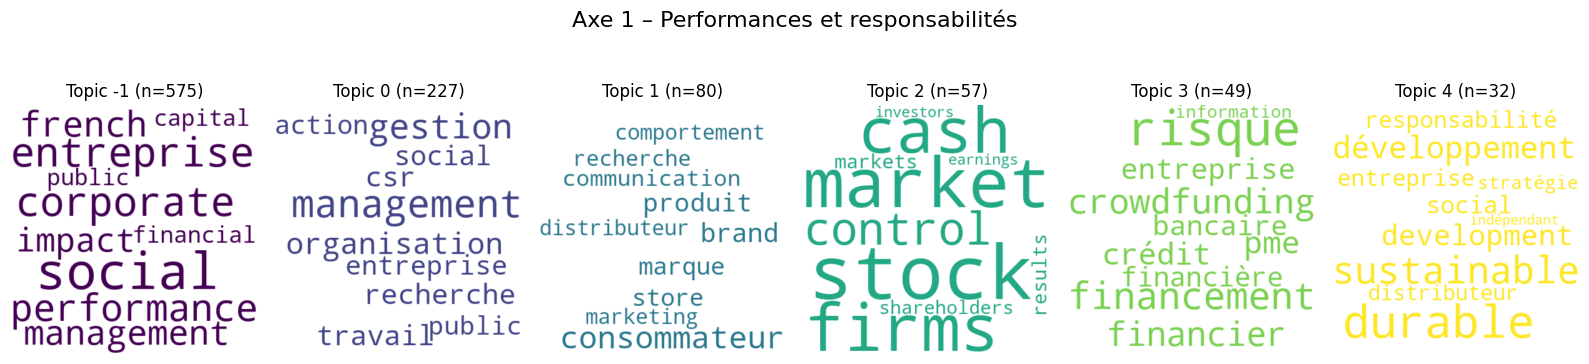

In [ ]:
import matplotlib.cm as cm
import matplotlib.pyplot as plt

topic_ids = topic_info['Topic'].tolist()
print(topic_ids)
cmap = cm.get_cmap("viridis", len(topic_ids))  # len(topic_ids) 个颜色
topic_colors = {topic_id: cmap(i) for i, topic_id in enumerate(topic_ids)}

from wordcloud import WordCloud
fig, axes = plt.subplots(1, len(topic_ids), figsize=(16,4))
for ax, topic_id in zip(axes, topic_ids):
    words = dict(topic_model.get_topic(topic_id))#{word:weight}    
    count = topic_info.loc[topic_info.Topic==topic_id, 'Count'].values[0]# showed in title
    
    
    # #words2
    # topic_words = topic_model.get_topic(topic_id)  # list of (word, weight)
    # count = topic_info.loc[topic_info.Topic == topic_id, 'Count'].values[0]  # 该 topic 文档数
    # threshold = 0.01
    # words = {word: weight * count for word, weight in topic_words if weight * count >= threshold}

    # WordCloud 支持 colormap
    wc = WordCloud(
        background_color="white",
        colormap=cm.colors.ListedColormap([topic_colors[topic_id]]),  # 每个 topic 单色
        width=400,
        height=400
    ).generate_from_frequencies(words)

    ax.imshow(wc, interpolation='bilinear')
    # ax.set_title(f"Topic {topic_id}", fontsize=12)
    ax.set_title(f"Topic {topic_id} (n={count})", fontsize=12)

    ax.axis("off")

fig.suptitle(f"Axe {axe_id} – {axe_label.get(axe_id)}", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

## try2

In [ ]:
# df=df_predicted.copy()

# def parse_axes(x):
#     if pd.isna(x):
#         return []
#     return [a.strip() for a in str(x).split(';')]
# df=df_predicted.copy()
# df['axe_list'] = df['final_axe'].apply(parse_axes)


# #Step 2：合并三种 embedding（稳健版本）
# def combine_embeddings(row, w_title=1.0, w_kw=1.2, w_abs=1.5):
#     vecs = []
#     weights = []

#     if isinstance(row['emb_title_s'], np.ndarray):
#         vecs.append(row['emb_title_s'])
#         weights.append(w_title)

#     if isinstance(row['emb_keyword_s'], np.ndarray):
#         vecs.append(row['emb_keyword_s'])
#         weights.append(w_kw)

#     if isinstance(row['emb_abstract_s'], np.ndarray):
#         vecs.append(row['emb_abstract_s'])
#         weights.append(w_abs)

#     if not vecs:
#         return None

#     return np.average(vecs, axis=0, weights=weights)
# df['combined_emb'] = df.apply(combine_embeddings, axis=1)


# print(df['combined_emb'].shape)  # shape = (n_articles, emb_dim)
# print(df['axe_list'])    # e.g. ['1'], ['1','3']

# X = np.vstack(df['combined_emb'].dropna().values)
# df_plot = df.loc[df['combined_emb'].notna()].copy()


d:\miniconda3\envs\irg_env\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


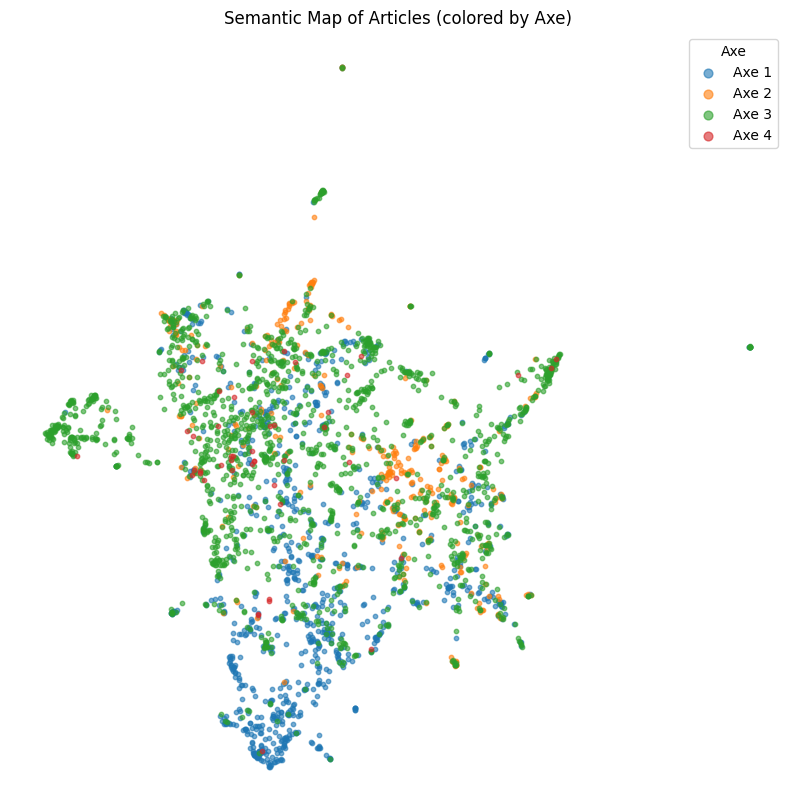

In [16]:
import umap

df_plot=df_plot_exploded.copy()
reducer = umap.UMAP(
    n_neighbors=15,
    min_dist=0.1,
    metric='cosine',
    random_state=42
)

X_2d = reducer.fit_transform(X)
df_plot['x'] = X_2d[:, 0]
df_plot['y'] = X_2d[:, 1]


# def main_axe(axes):
#     return axes[0] if axes else None

# df_plot['main_axe'] = df_plot['axe_list'].apply(main_axe)

plt.figure(figsize=(10, 10))

for axe, g in df_plot.groupby('final_axe'):
    plt.scatter(
        g['x'], g['y'],
        s=10,
        alpha=0.6,
        label=f"Axe {axe}"
    )

plt.legend(title="Axe", markerscale=2)
plt.title("Semantic Map of Articles (colored by Axe)")
plt.axis('off')
plt.show()


In [ ]:
for axe, emb in axe_embeddings.items():
    center = reducer.transform(emb.reshape(1, -1))
    plt.scatter(center[0,0], center[0,1],
                s=300, marker='X', edgecolor='black')
    plt.text(center[0,0], center[0,1], f"Axe {axe}",
             fontsize=12, weight='bold')




## TRY1

In [ ]:

import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

from sklearn.metrics.pairwise import cosine_similarity


In [ ]:
def parse_axes(x):
    if pd.isna(x):
        return []
    return [a.strip() for a in str(x).split(';')]
df=df_predicted.copy()
df['axe_list'] = df['final_axe'].apply(parse_axes)


#Step 2：合并三种 embedding（稳健版本）
def combine_embeddings(row, w_title=1.0, w_kw=1.2, w_abs=1.5):
    vecs = []
    weights = []

    if isinstance(row['emb_title_s'], np.ndarray):
        vecs.append(row['emb_title_s'])
        weights.append(w_title)

    if isinstance(row['emb_keyword_s'], np.ndarray):
        vecs.append(row['emb_keyword_s'])
        weights.append(w_kw)

    if isinstance(row['emb_abstract_s'], np.ndarray):
        vecs.append(row['emb_abstract_s'])
        weights.append(w_abs)

    if not vecs:
        return None

    return np.average(vecs, axis=0, weights=weights)
df['combined_emb'] = df.apply(combine_embeddings, axis=1)



#Step 3：按 axe 聚合语义向量（关键）
axe_embeddings = {}
all_axes = sorted({a for axes in df['axe_list'] for a in axes})

for axe in all_axes:
    idx = df['axe_list'].apply(lambda x: axe in x)
    emb_list = df.loc[idx, 'combined_emb'].dropna().tolist()

    if emb_list:
        axe_embeddings[axe] = np.vstack(emb_list).mean(axis=0)


# Step 4：计算 axe–axe 语义相似度
axes = list(axe_embeddings.keys())
E = np.vstack([axe_embeddings[a] for a in axes])

S = cosine_similarity(E)
pd.DataFrame(S, index=axes, columns=axes)


,1,2,3,4
1,1.000000,0.970100,0.980873,0.950529
2,0.970100,1.000000,0.981196,0.950960
3,0.980873,0.981196,1.000000,0.966930
4,0.950529,0.950960,0.966930,1.000000


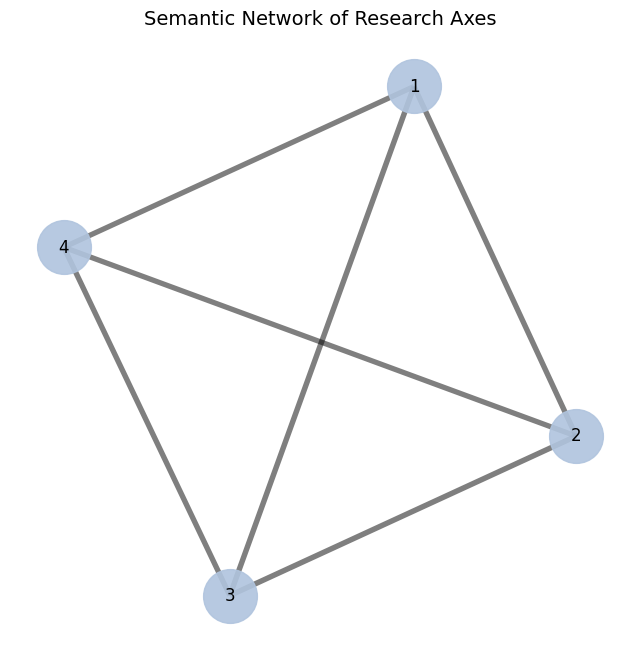

In [12]:
# Step 5：构建语义网络
G = nx.Graph()

for axe in axes:
    G.add_node(axe)

threshold = 0.3
for i, a1 in enumerate(axes):
    for j, a2 in enumerate(axes):
        if i < j and S[i, j] >= threshold:
            G.add_edge(a1, a2, weight=S[i, j])



# Step 6：力导向布局 + 可视化
pos = nx.spring_layout(G, weight='weight', seed=42)
plt.figure(figsize=(8, 8))

nx.draw_networkx_nodes(
    G, pos,
    node_size=1500,
    node_color='lightsteelblue',
    alpha=0.9
)

nx.draw_networkx_edges(
    G, pos,
    width=[G[u][v]['weight'] * 4 for u, v in G.edges()],
    alpha=0.5
)

nx.draw_networkx_labels(
    G, pos,
    font_size=12
)

plt.title("Semantic Network of Research Axes", fontsize=14)
plt.axis('off')
plt.show()


In [4]:
from utils.preprocess import explode_by_col
df_split=explode_by_col(df_predicted, col='final_axe')
print(len(df_predicted), len(df_split))
print(df_split.final_axe.value_counts(dropna=False))
print(df_split.language_s.value_counts(dropna=False))
# print(df_split.final_axe.dtype)
# display(df_split.head())

2734 3036
final_axe
3    1596
1    1020
2     373
4      47
Name: count, dtype: int64
language_s
fr    1834
en    1190
pt       5
es       4
ru       1
it       1
pl       1
Name: count, dtype: int64


## tfidf:

In [61]:
from sklearn.feature_extraction.text import TfidfVectorizer
import json

path_stopwords='../external_data\stopwords_nltk.json'
with open(path_stopwords,'r', encoding='utf-8')as f:
    stopwords=json.load(f)

df_split["all_text"] = (
    df_split[["title_s", "keyword_s", "abstract_s"]]
    .fillna("")
    .agg(" ".join, axis=1)
    .str.strip()
)
display(df_split[['title_s','keyword_s','abstract_s','all_text']].head())

df_split_notna=df_split[df_split['all_text'].notna()]



print(len(df_split),len(df_split_notna))
print(df_split_notna.final_axe.value_counts(dropna=False))

vectorizer = TfidfVectorizer(
    max_features=3000,
    stop_words=stopwords,  # 或自定义
    ngram_range=(1,2)
)

X_tfidf = vectorizer.fit_transform(df_split_notna["all_text"])
print(X_tfidf.shape)

feature_names = np.array(vectorizer.get_feature_names_out())

,title_s,keyword_s,abstract_s,all_text
0,Entrepreneuriat de nécessité (versus opportuni...,NaN,Cet article étudie les déterminants de l’entre...,Entrepreneuriat de nécessité (versus opportuni...
0,Entrepreneuriat de nécessité (versus opportuni...,NaN,Cet article étudie les déterminants de l’entre...,Entrepreneuriat de nécessité (versus opportuni...
1,Responsible entrepreneurship: From motivations...,Burkina Faso; GEM; Modèle de la valeur; Entrep...,Cet article étudie les déterminants des modèle...,Responsible entrepreneurship: From motivations...
1,Responsible entrepreneurship: From motivations...,Burkina Faso; GEM; Modèle de la valeur; Entrep...,Cet article étudie les déterminants des modèle...,Responsible entrepreneurship: From motivations...
2,Agencer des safe spaces en marketing des servi...,Marketing des services; Sécurité; Transformati...,NaN,Agencer des safe spaces en marketing des servi...


3039 3039
final_axe
3      1546
1       994
2       405
4        85
nan       9
Name: count, dtype: int64
(3039, 3000)


In [62]:
# def top_terms_for_axe(axe_label, top_k=15):
#     idx = df_split_abstract["final_axe"] == axe_label
#     tfidf_mean = X_tfidf[idx].mean(axis=0)
#     top_idx = np.argsort(tfidf_mean.A1)[::-1][:top_k]
#     return feature_names[top_idx]

def top_terms_for_axe(axe_label, top_k=15):
    idx = (df_split_notna["final_axe"] == axe_label).values
    tfidf_mean = X_tfidf[idx].mean(axis=0)
    top_idx = np.argsort(tfidf_mean.A1)[::-1][:top_k]
    return feature_names[top_idx]

dict_axes={
    "1": "Performances et responsabilités",
    "2": "Société de services et services à la société",
    "3": "Innovations, transformations et résistances organisationnelles et sociétales",
    "4": "Ouvrages pédagogiques"
}


for axe in ["1","2","3","4"]:
    kw=top_terms_for_axe(axe_label=axe, top_k=15)
    print(f"AXE {dict_axes.get(axe,None)}: \n{kw}\n")
    


AXE Performances et responsabilités: 
['management' 'performance' 'entreprises' 'corporate' 'gestion' 'social'
 'capital' 'rse' 'entreprise' 'financial' 'france' 'market' 'sociale'
 'french' 'firms']

AXE Société de services et services à la société: 
['service' 'marketing' 'client' 'services' 'customer' 'management'
 'relation' 'participation' 'travail' 'clients' 'recherche' 'santé'
 'research' 'confiance' 'place']

AXE Innovations, transformations et résistances organisationnelles et sociétales: 
['management' 'innovation' 'recherche' 'gestion' 'luxe' 'ludopédagogie'
 'travail' 'marketing' 'research' 'changement' 'pratiques' 'france'
 'parfumerie' 'organisations' 'organizational']

AXE Ouvrages pédagogiques: 
['recherche' 'management' 'cas' 'gestion' 'ouvrage' 'marketing'
 'ressources' 'collecte' 'finance' 'cet ouvrage' 'grh' 'formation'
 'chapitre' 'action' 'cet']



In [64]:
from itertools import combinations
from collections import Counter
nodes = top_terms_for_axe("1", top_k=30)

edges = Counter()
for text in df_split_notna[df_split_notna["final_axe"]=="1"]["all_text"]:
    words = set(text.split()) & set(nodes)
    for pair in combinations(words, 2):
        edges[pair] += 1
edges

Counter({('recherche', 'article'): 23,
         ('recherche', 'sociale'): 6,
         ('article', 'sociale'): 12,
         ('développement', 'durable'): 31,
         ('développement', 'article'): 16,
         ('développement', 'corporate'): 4,
         ('développement', 'sociale'): 15,
         ('développement', 'performance'): 5,
         ('durable', 'article'): 9,
         ('durable', 'corporate'): 3,
         ('durable', 'sociale'): 11,
         ('durable', 'performance'): 4,
         ('article', 'corporate'): 6,
         ('article', 'performance'): 14,
         ('corporate', 'sociale'): 2,
         ('corporate', 'performance'): 19,
         ('sociale', 'performance'): 8,
         ('social', 'développement'): 10,
         ('social', 'durable'): 8,
         ('social', 'sociale'): 27,
         ('social', 'recherche'): 15,
         ('développement', 'recherche'): 23,
         ('durable', 'recherche'): 10,
         ('sociale', 'recherche'): 8,
         ('sociale', 'innovation'): 1,
    

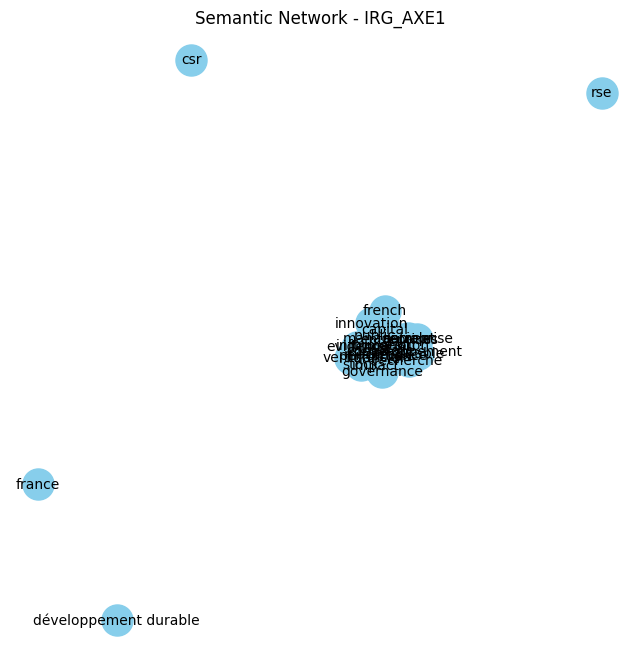

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt

G = nx.Graph()
G.add_nodes_from(nodes)
for (w1, w2), weight in edges.items():
    G.add_edge(w1, w2, weight=weight)

plt.figure(figsize=(8,8))
pos = nx.spring_layout(G, k=0.3)
nx.draw_networkx_nodes(G, pos, node_size=500, node_color="skyblue")
nx.draw_networkx_edges(G, pos, width=[d['weight']*0.2 for (u,v,d) in G.edges(data=True)])
nx.draw_networkx_labels(G, pos, font_size=10)
plt.title("Réseau sémantique")
plt.axis("off")
plt.show()


## clustering within axe:

In [ ]:
from sklearn.cluster import KMeans

def cluster_within_axe(axe_label, k=2):
    idx = df["final_axe"] == axe_label
    X = np.stack(df.loc[idx, "emb_abstract_s"])
    km = KMeans(n_clusters=k, random_state=42)
    labels = km.fit_predict(X)
    return labels
